# Agenda



Cross validation

Linear models
    Ordinary Least Squares or Simple Linear regression and Multiple linear regression

    Bias-variance trade off and Learning curve
    
    Assumptions of Linear regression
    
    Feature engineering - Polynomial terms to handle non-linearity & Interaction terms
    
    Regularization
    
    Strengths, Weaknesses and Use cases

# Cross validation

Cross validation allows us to compare different machine learning methods and get a sense of how well they work in practice.

How do we know that using 75% of data for training and the last 25% of data for testing is the best way to divide the data ?

Imagine you logically split the data into multiple blocks. Rather than worry about which block would be best for testing, cross validation uses them all, one at a time, and summarizes the results at the end.

<img src="./images/cross_validation_1.png" alt="sample" width="1000"/>

<img src="./images/cross_validation_2.png" alt="sample" width="1000"/>

<img src="./images/cross_validation_3.png" alt="sample" width="1000"/>

Best k: 8
Best CV RMSE: 0.6309391336343767


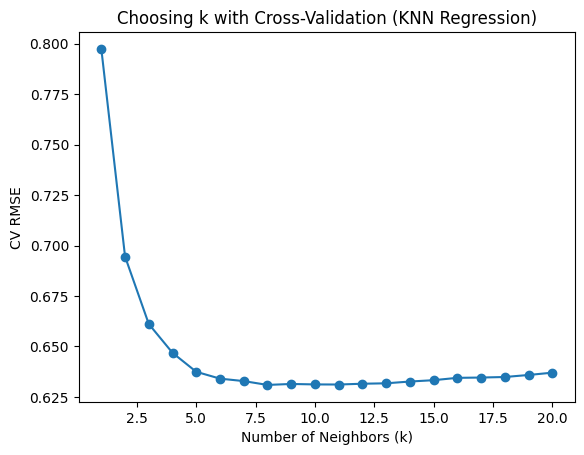

In [ ]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import cross_val_score, KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1) Load data
X, y = fetch_california_housing(return_X_y=True)

# 2) Cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 3) Range of k values to test
k_values = range(1, 21)   # from 1 to 20 neighbors
cv_scores = []

# 4) Loop through k values
for k in k_values:
    # Build pipeline (scaling + KNN)
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=k))
    ])
    
    # Negative RMSE scoring (neg because sklearn wants "higher is better")
    scores = cross_val_score(pipe, X, y, cv=cv,
                             scoring="neg_root_mean_squared_error",
                             n_jobs=-1)
    
    # Store mean score
    cv_scores.append(-scores.mean())

# 5) Find best k
best_k = k_values[np.argmin(cv_scores)]
best_score = min(cv_scores)

print("Best k:", best_k)
print("Best CV RMSE:", best_score)

# 6) Optional: Plot performance curve - a.k.a ELBOW method
import matplotlib.pyplot as plt
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("CV RMSE")
plt.title("Choosing k with Cross-Validation (KNN Regression)")
plt.show()

# Ordinary Least Squares a.k.a Linear Regression

<img src="./images/linear_regression_12.png" alt="sample" width="1000"/>

<img src="./images/linear_regression_13.png" alt="sample" width="1000"/>

<img src="./images/linear_regression_14.png" alt="sample" width="1000"/>

<img src="./images/linear_regression_15.png" alt="sample" width="1000"/>

<img src="./images/linear_regression_16.png" alt="sample" width="1000"/>

<img src="./images/linear_regression_17.png" alt="sample" width="1000"/>

<img src="./images/linear_regression_18.png" alt="sample" width="1000"/>

<img src="./images/linear_regression_1.png" alt="sample" width="1000"/>

<img src="./images/linear_regression_2.png" alt="sample" width="1000"/>

<img src="./images/linear_regression_3.png" alt="sample" width="1000"/>

<img src="./images/linear_regression_4.png" alt="sample" width="1000"/>

<img src="./images/linear_regression_5.png" alt="sample" width="1000"/>

<img src="./images/linear_regression_6.png" alt="sample" width="1000"/>

<img src="./images/linear_regression_7.png" alt="sample" width="1000"/>

<img src="./images/linear_regression_8.png" alt="sample" width="1000"/>

<img src="./images/linear_regression_9.png" alt="sample" width="1000"/>

<img src="./images/linear_regression_10.png" alt="sample" width="1000"/>

<img src="./images/linear_regression_11.png" alt="sample" width="1000"/>

In [58]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import f as f_dist

# ----------------------------
# 1) Load dataset
# ----------------------------
data = fetch_california_housing(as_frame=True)
X = data.data            # 8 numeric predictors
y = data.target          # MedianHouseValue (in 100k USD)

# Optional: quick peek
# print(X.head(), y.head())

# ----------------------------
# 2) Train / Test split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------
# 3) Fit Linear Regression
# ----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# Extract equation components
intercept = model.intercept_
coefficients = model.coef_

print("Intercept (β0):", intercept)
print("Coefficient (β1):", coefficients)

# Put equation into readable form
eq_parts = [f"({coef:.3f})*{col}" for col, coef in zip(X.columns, coefficients)]
equation = " + ".join(eq_parts)
print(f"Line of best fit: y = {intercept:.3f} + {equation}")

# ----------------------------
# 4) Predictions & metrics
# ----------------------------
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

def metrics(y_true, y_pred):
    r2  = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    return r2, mse, rmse, mae

r2_tr, mse_tr, rmse_tr, mae_tr = metrics(y_train, y_pred_train)
r2_te, mse_te, rmse_te, mae_te = metrics(y_test, y_pred_test)

# Adjusted R^2 (use training set for model fit statistics)
n = X_train.shape[0]     # number of observations in training
k = X_train.shape[1]     # number of predictors
adj_r2_tr = 1 - (1 - r2_tr) * (n - 1) / (n - k - 1)

# ----------------------------
# 5) Overall F-statistic for the model (tests significance of R^2)
#    F = (R^2 / k) / ((1 - R^2) / (n - k - 1))
#    df1 = k, df2 = n - k - 1
# ----------------------------
df1 = k
df2 = n - k - 1
F = (r2_tr / df1) / ((1 - r2_tr) / df2)

# p-value for overall significance (right-tail)
p_value = 1 - f_dist.cdf(F, df1, df2)

# ----------------------------
# 6) Print results
# ----------------------------
print("=== Linear Regression on California Housing ===")
print(f"Intercept: {model.intercept_:.6f}")
print("Coefficients (aligned with columns):")
for name, coef in zip(X.columns, model.coef_):
    print(f"  {name:>12s}: {coef:.6f}")

print("\n--- Training Performance ---")
print(f"R^2 (train):        {r2_tr:.6f}")
print(f"Adjusted R^2:       {adj_r2_tr:.6f}")
print(f"MSE (train):        {mse_tr:.6f}")
print(f"RMSE (train):       {rmse_tr:.6f}")
print(f"MAE (train):        {mae_tr:.6f}")

print("\n--- Test Performance ---")
print(f"R^2 (test):         {r2_te:.6f}")
print(f"MSE (test):         {mse_te:.6f}")
print(f"RMSE (test):        {rmse_te:.6f}")
print(f"MAE (test):         {mae_te:.6f}")

print("\n--- Overall Significance of the Model ---")
print(f"F-statistic:        {F:.6f}")
print(f"df1 (numerator):    {df1}")
print(f"df2 (denominator):  {df2}")
print(f"p-value:            {p_value:.6e}")
print("\nInterpretation: If p-value < 0.05, the model explains a statistically "
      "significant proportion of variance in y (i.e., R^2 is significant).")

Intercept (β0): -37.02327770606405
Coefficient (β1): [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
Line of best fit: y = -37.023 + (0.449)*MedInc + (0.010)*HouseAge + (-0.123)*AveRooms + (0.783)*AveBedrms + (-0.000)*Population + (-0.004)*AveOccup + (-0.420)*Latitude + (-0.434)*Longitude
=== Linear Regression on California Housing ===
Intercept: -37.023278
Coefficients (aligned with columns):
        MedInc: 0.448675
      HouseAge: 0.009724
      AveRooms: -0.123323
     AveBedrms: 0.783145
    Population: -0.000002
      AveOccup: -0.003526
      Latitude: -0.419792
     Longitude: -0.433708

--- Training Performance ---
R^2 (train):        0.612551
Adjusted R^2:       0.612363
MSE (train):        0.517933
RMSE (train):       0.719676
MAE (train):        0.528628

--- Test Performance ---
R^2 (test):         0.575788
MSE (test):         0.555892
RMSE (test):        0.745581
MAE (test):         0.53320

/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/manojkumar_rajen

Training accuracy (or R², or low error) tells you how well the model has learned patterns in the data it was given.

If training accuracy is very low, it means, model is too simple → underfitting (e.g., using linear regression for a non-linear problem).

If training accuracy is very high (near perfect), that might mean, model could be overfitting (memorizing instead of generalizing).

So, training accuracy is the first check that your model is working at all.

High training accuracy + low test accuracy → Overfitting.

Low training accuracy + low test accuracy → Underfitting.

Good balance → Model generalizes well.


<img src="./images/Accuracy_vs_Model_Complexity.png" alt="sample" width="1000"/>

<img src="./images/Learning_Curve_Accuracy_vs_Training_Set_Size.png" alt="sample" width="1000"/>

# Assumptions of Linear Regression

1)  Linearity - The relationship between predictors (X) and the target (Y) is assumed to be linear in nature. This means that a one-unit change in a predictor results in a proportional change in the outcome, holding other predictors constant. If the true relationship is curved or more complex, the linear model will underfit, leading to biased estimates.

2)  Independence - Each observation (data point) should be independent of the others. In other words, the error (residual) for one observation should not depend on or be correlated with the error for another. If data points are dependent (e.g., in time series or clustered data), the model’s standard errors and significance tests become invalid.

3)  Homoscedasticity - The variance of the residuals should remain constant across all values of predictors. If residuals fan out or shrink as predictor values change, it indicates heteroscedasticity. 

4)  No Multicollinearity 0 Predictors (independent variables) should not be too highly correlated with one another. If two or more predictors are strongly correlated, it becomes difficult to separate out their individual effects on Y. This leads to unstable coefficient estimates and inflated standard errors, making interpretation difficult.


# Feature engineering

In [59]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import f as f_dist

# ----------------------------
# 1) Config: degree & interactions
# ----------------------------
POLY_DEGREE = 2              # 2 adds quadratics + pairwise interactions
INTERACTION_ONLY = False     # True -> only interactions, no X^2 terms
INCLUDE_BIAS = False         # keep False because LinearRegression adds intercept

# ----------------------------
# 2) Load dataset
# ----------------------------
data = fetch_california_housing(as_frame=True)
X = data.data            # 8 numeric predictors
y = data.target          # MedianHouseValue (in 100k USD)
feature_names = X.columns.to_list()

# ----------------------------
# 3) Train / Test split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------
# 4) Build pipeline: Scale -> Polynomial/Interactions -> Linear Regression
# ----------------------------
poly = PolynomialFeatures(
    degree=POLY_DEGREE,
    interaction_only=INTERACTION_ONLY,
    include_bias=INCLUDE_BIAS
)

pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),      # important for distance-based models & well-conditioned design
    ("poly", poly),
    ("linreg", LinearRegression())
])

# ----------------------------
# 5) Fit
# ----------------------------
pipe.fit(X_train, y_train)

# Access fitted components
fitted_poly = pipe.named_steps["poly"]
linreg = pipe.named_steps["linreg"]

# Expanded feature names AFTER polynomial expansion
expanded_feature_names = fitted_poly.get_feature_names_out(feature_names)

# ----------------------------
# 6) Extract equation components
# ----------------------------
intercept = linreg.intercept_
coefficients = linreg.coef_

print("=== Model with Polynomial & Interaction Terms ===")
print(f"Degree: {POLY_DEGREE} | interaction_only={INTERACTION_ONLY}")
print(f"Number of original features: {len(feature_names)}")
print(f"Number of expanded features: {len(expanded_feature_names)}\n")

print(f"Intercept (β0): {intercept:.6f}")
print("Coefficients (aligned with expanded columns):")
for name, coef in zip(expanded_feature_names, coefficients):
    print(f"  {name:>20s}: {coef:.6f}")

# Optional: human-readable "equation" (very long with many terms)
eq_parts = [f"({coef:.4f})*{name}" for name, coef in zip(expanded_feature_names, coefficients)]
equation = " + ".join(eq_parts)
print("\nLine of best fit (expanded):")
print(f"y = {intercept:.4f} + {equation}\n")

# ----------------------------
# 7) Predictions & metrics
# ----------------------------
y_pred_train = pipe.predict(X_train)
y_pred_test  = pipe.predict(X_test)

def metrics(y_true, y_pred):
    r2  = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    return r2, mse, rmse, mae

r2_tr, mse_tr, rmse_tr, mae_tr = metrics(y_train, y_pred_train)
r2_te, mse_te, rmse_te, mae_te = metrics(y_test, y_pred_test)

# ----------------------------
# 8) Adjusted R^2 (use training set)
#    n = number of training observations
#    k = number of expanded predictors (after poly), not counting intercept
# ----------------------------
n = X_train.shape[0]
k = len(expanded_feature_names)
adj_r2_tr = 1 - (1 - r2_tr) * (n - 1) / (n - k - 1)

# ----------------------------
# 9) Overall F-statistic for the model (tests significance of R^2 on train)
#    F = (R^2 / k) / ((1 - R^2) / (n - k - 1))
#    df1 = k, df2 = n - k - 1
# ----------------------------
df1 = k
df2 = n - k - 1
F = (r2_tr / df1) / ((1 - r2_tr) / df2)
p_value = 1 - f_dist.cdf(F, df1, df2)

# ----------------------------
# 10) Print results
# ----------------------------
print("=== Performance ===")
print("--- Training ---")
print(f"R^2 (train):        {r2_tr:.6f}")
print(f"Adjusted R^2:       {adj_r2_tr:.6f}")
print(f"MSE (train):        {mse_tr:.6f}")
print(f"RMSE (train):       {rmse_tr:.6f}")
print(f"MAE (train):        {mae_tr:.6f}")

print("\n--- Test ---")
print(f"R^2 (test):         {r2_te:.6f}")
print(f"MSE (test):         {mse_te:.6f}")
print(f"RMSE (test):        {rmse_te:.6f}")
print(f"MAE (test):         {mae_te:.6f}")

print("\n--- Overall Significance (train) ---")
print(f"F-statistic:        {F:.6f}")
print(f"df1 (numerator):    {df1}")
print(f"df2 (denominator):  {df2}")
print(f"p-value:            {p_value:.6e}")
print("\nInterpretation: If p-value < 0.05, the expanded model explains a statistically "
      "significant proportion of variance in y (i.e., R^2 is significant).")

=== Model with Polynomial & Interaction Terms ===
Degree: 2 | interaction_only=False
Number of original features: 8
Number of expanded features: 44

Intercept (β0): 1.956590
Coefficients (aligned with expanded columns):
                MedInc: 0.935940
              HouseAge: 0.132058
              AveRooms: -0.387599
             AveBedrms: 0.530207
            Population: 0.040513
              AveOccup: -1.781263
              Latitude: -1.272679
             Longitude: -1.167630
              MedInc^2: -0.112226
       MedInc HouseAge: 0.037846
       MedInc AveRooms: 0.179781
      MedInc AveBedrms: -0.120152
     MedInc Population: 0.111430
       MedInc AveOccup: -0.098840
       MedInc Latitude: -0.667216
      MedInc Longitude: -0.586169
            HouseAge^2: 0.033291
     HouseAge AveRooms: -0.016247
    HouseAge AveBedrms: 0.052345
   HouseAge Population: 0.036025
     HouseAge AveOccup: -0.278667
     HouseAge Latitude: -0.276779
    HouseAge Longitude: -0.252813
        

/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/manojkumar_rajen

# Regularization

In [60]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ----------------------------
# Config
# ----------------------------
POLY_DEGREE = 2              # degree for polynomial features
INTERACTION_ONLY = False     # set True to keep only interactions (no squares)
INCLUDE_BIAS = False         # intercept handled by estimator
RANDOM_STATE = 42

# Alphas to search in CV
RIDGE_ALPHAS = np.logspace(-4, 3, 20)   # 1e-4 ... 1e3
LASSO_ALPHAS = np.logspace(-4, 1, 30)   # 1e-4 ... 10

# CV splitter
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ----------------------------
# Load data
# ----------------------------
data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target
feature_names = X.columns.to_list()

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# ----------------------------
# Helpers
# ----------------------------
def eval_metrics(y_true, y_pred):
    r2  = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    return r2, rmse, mae

def adjusted_r2(r2, n, k):
    # n: samples, k: number of predictors (expanded features, no intercept)
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

def count_nonzero(coefs, tol=1e-12):
    return int(np.sum(np.abs(coefs) > tol))

def run_model(estimator, name):
    """
    Build pipeline: Poly -> Scale -> Estimator
    Fit, evaluate, and print metrics & sparsity.
    """
    pipe = Pipeline(steps=[
        ("poly", PolynomialFeatures(
            degree=POLY_DEGREE,
            interaction_only=INTERACTION_ONLY,
            include_bias=INCLUDE_BIAS
        )),
        ("scaler", StandardScaler()),
        (name, estimator)
    ])

    pipe.fit(X_train, y_train)

    # Expanded feature names after poly
    expanded_names = pipe.named_steps["poly"].get_feature_names_out(feature_names)

    # Predictions
    y_pred_tr = pipe.predict(X_train)
    y_pred_te = pipe.predict(X_test)

    # Metrics
    r2_tr, rmse_tr, mae_tr = eval_metrics(y_train, y_pred_tr)
    r2_te, rmse_te, mae_te = eval_metrics(y_test,  y_pred_te)

    # Adjusted R^2 uses number of expanded predictors
    n = X_train.shape[0]
    k = len(expanded_names)
    adj_r2_tr = adjusted_r2(r2_tr, n, k)

    # Coefficients / intercept
    est = pipe.named_steps[name]
    if hasattr(est, "coef_"):
        coefs = est.coef_
        intercept = est.intercept_
    else:
        # For CV estimators it’s the same
        coefs = est.coef_
        intercept = est.intercept_

    nnz = count_nonzero(coefs)

    print(f"\n=== {name.upper()} Results (degree={POLY_DEGREE}, interaction_only={INTERACTION_ONLY}) ===")
    if hasattr(est, "alpha_"):
        print(f"Chosen alpha (CV): {getattr(est, 'alpha_'):.6f}")
    print(f"Expanded features: {k}")
    print(f"Intercept: {intercept:.6f}")
    print(f"Non-zero coefficients: {nnz} / {k}")

    print("\n--- Training ---")
    print(f"R^2:              {r2_tr:.6f}")
    print(f"Adjusted R^2:     {adj_r2_tr:.6f}")
    print(f"RMSE:             {rmse_tr:.6f}")
    print(f"MAE:              {mae_tr:.6f}")

    print("\n--- Test ---")
    print(f"R^2:              {r2_te:.6f}")
    print(f"RMSE:             {rmse_te:.6f}")
    print(f"MAE:              {mae_te:.6f}")

    # Show top 10 coefficients by absolute magnitude (for interpretability)
    top_idx = np.argsort(np.abs(coefs))[-10:][::-1]
    print("\nTop 10 |coef| features:")
    for i in top_idx:
        print(f"{expanded_names[i]:>25s}: {coefs[i]:.6f}")

    return {
        "pipeline": pipe,
        "expanded_names": expanded_names,
        "coefs": coefs,
        "intercept": intercept,
        "metrics": {
            "train": {"r2": r2_tr, "adj_r2": adj_r2_tr, "rmse": rmse_tr, "mae": mae_tr},
            "test":  {"r2": r2_te, "rmse": rmse_te, "mae": mae_te},
        },
        "alpha": getattr(est, "alpha_", None),
        "nnz": nnz,
        "k": k
    }

# ----------------------------
# Run Baseline OLS (no regularization)
# ----------------------------
ols_res = run_model(
    estimator=LinearRegression(),
    name="linreg"
)

# ----------------------------
# Run L1 Regularization (LassoCV) — feature selection + shrinkage
# ----------------------------
lasso_res = run_model(
    estimator=LassoCV(alphas=LASSO_ALPHAS, cv=cv, random_state=RANDOM_STATE, max_iter=20000),
    name="lasso"
)

# ----------------------------
# Run L2 Regularization (RidgeCV) — shrinkage, stability
# ----------------------------
ridge_res = run_model(
    estimator=RidgeCV(alphas=RIDGE_ALPHAS, cv=cv),
    name="ridge"
)

# ----------------------------
# Quick Comparison Summary
# ----------------------------
def summarize(label, res):
    tr = res["metrics"]["train"]
    te = res["metrics"]["test"]
    alpha = res["alpha"]
    nnz = res["nnz"]
    k = res["k"]
    print(f"{label:>8s} | alpha={alpha} | nz={nnz}/{k} | "
          f"Train R2={tr['r2']:.3f} (Adj={tr['adj_r2']:.3f}) | "
          f"Test R2={te['r2']:.3f} | Test RMSE={te['rmse']:.3f} | Test MAE={te['mae']:.3f}")

print("\n=== Summary (compare generalization) ===")
summarize("OLS",   ols_res)
summarize("LASSO", lasso_res)
summarize("RIDGE", ridge_res)

print("\nNote:")
print("- LASSO (L1) can zero-out many polynomial/interaction terms (lower variance, simpler model).")
print("- RIDGE (L2) keeps all terms but shrinks them (handles multicollinearity well).")
print("- Expect baseline OLS to have higher train R²; a regularized model often improves **test R²** and reduces RMSE/MAE.")

/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/manojkumar_rajen


=== LINREG Results (degree=2, interaction_only=False) ===
Expanded features: 44
Intercept: 2.071947
Non-zero coefficients: 44 / 44

--- Training ---
R^2:              0.685268
Adjusted R^2:     0.684427
RMSE:             0.648634
MAE:              0.460838

--- Test ---
R^2:              0.645682
RMSE:             0.681397
MAE:              0.467001

Top 10 |coef| features:
         MedInc Longitude: -35.007094
       Latitude Longitude: 32.907035
       AveRooms Longitude: 28.590310
      AveBedrms Longitude: -25.193322
                   MedInc: -22.730426
       AveOccup Longitude: 22.252932
                 AveRooms: 18.821861
              Longitude^2: 18.291498
                 Latitude: 17.700966
                AveBedrms: -16.601630


/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 17.183102207451157, tolerance: 1.7669373150516783
  model = cd_fast.enet_coordinate_descent_gram(
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 13.908233611533433, tolerance: 1.7669373150516783
  model = cd_fast.enet_coordinate_descent_gram(
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3.8630564047252847, tolerance: 1.7669373150516783
  model = cd_fast.enet_coordinate_descent_gram


=== LASSO Results (degree=2, interaction_only=False) ===
Chosen alpha (CV): 0.007880
Expanded features: 44
Intercept: 2.071947
Non-zero coefficients: 16 / 44

--- Training ---
R^2:              0.617827
Adjusted R^2:     0.616806
RMSE:             0.714759
MAE:              0.525788

--- Test ---
R^2:              0.573305
RMSE:             0.747760
MAE:              0.530345

Top 10 |coef| features:
                 Latitude: -0.772735
                Longitude: -0.720952
         MedInc Longitude: -0.696391
          MedInc HouseAge: 0.171323
      AveBedrms Longitude: -0.117074
                 MedInc^2: -0.114173
         MedInc AveBedrms: 0.103556
        HouseAge AveRooms: -0.098793
       HouseAge AveBedrms: 0.095439
        AveRooms Latitude: -0.068775

=== RIDGE Results (degree=2, interaction_only=False) ===
Chosen alpha (CV): 1000.000000
Expanded features: 44
Intercept: 2.071947
Non-zero coefficients: 44 / 44

--- Training ---
R^2:              0.617785
Adjusted R^2:     0.6

/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_base.py:279:

# Strengths and Weaknesses

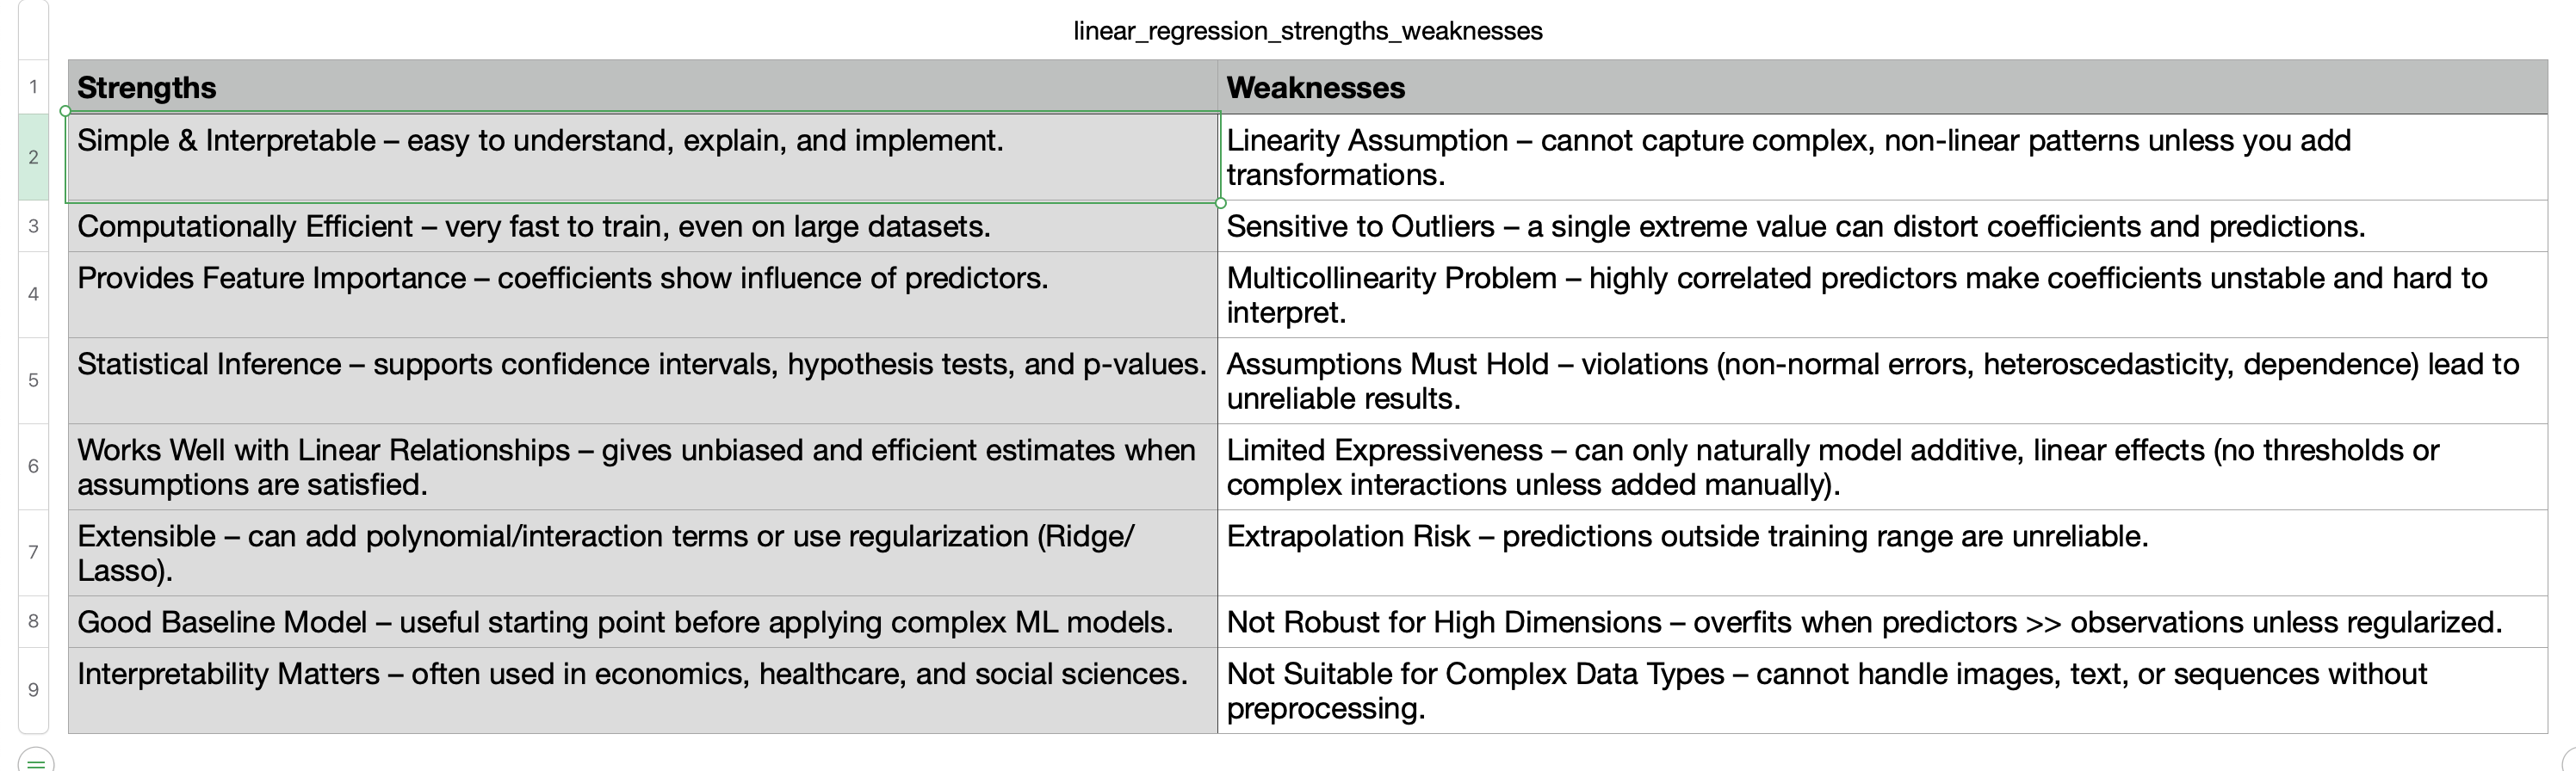